##Ejercicio 2



In [ ]:
import numpy as np
import unittest

class Quaternion:
    def __init__(self, w=1.0, x=0.0, y=0.0, z=0.0):
        norm = np.sqrt(w**2 + x**2 + y**2 + z**2)
        if norm < 1e-12:
            raise ValueError("El cuaternión no puede tener norma nula.")
        self.w = float(w / norm)
        self.x = float(x / norm)
        self.y = float(y / norm)
        self.z = float(z / norm)

## Retorna la parte vectorial como arreglo de NumPy [x, y, z]
    @property
    def v(self):
        return np.array([self.x, self.y, self.z], dtype=float)

##  Crea un cuaternión a partir de un eje arbitrario y un ángulo en radianes.
    @classmethod
    def from_axis_angle(cls, axis, angle_rad):
      axis = np.array(axis, dtype=float)
      norm_axis = np.linalg.norm(axis)
      if norm_axis < 1e-12:
        raise ValueError("El eje de rotación no puede ser un vector nulo.")

      u = axis / norm_axis
      w = np.cos(angle_rad / 2.0)
      v = u * np.sin(angle_rad / 2.0)
      return cls(w, v[0], v[1], v[2])


## Crea un cuaternión a partir de ángulos de Euler en secuencia ZYZ
    @classmethod
    def from_euler_zyz(cls, phi, theta, psi):
        q_phi = cls.from_axis_angle([0, 0, 1], phi)
        q_theta = cls.from_axis_angle([0, 1, 0], theta)
        q_psi = cls.from_axis_angle([0, 0, 1], psi)
        return q_phi * q_theta * q_psi

##Producto de Hamilton
    def __mul__(self, other):
        if isinstance(other, Quaternion):
            w1, v1 = self.w, self.v
            w2, v2 = other.w, other.v

            w_res = w1 * w2 - np.dot(v1, v2)
            v_res = w1 * v2 + w2 * v1 + np.cross(v1, v2)
            return Quaternion(w_res, v_res[0], v_res[1], v_res[2])
        else:
            raise TypeError("La multiplicación solo está definida entre objetos Quaternion.")


##Rota un vector 3D mediante la fórmula de Rodrigues (operador sándwich)
    def rotate_vector(self, p):
        p = np.array(p, dtype=float)
        v = self.v
        w = self.w
        return (w**2 - np.dot(v, v)) * p + 2.0 * np.dot(v, p) * v + 2.0 * w * np.cross(v, p)

    def to_rotation_matrix(self):
        w, x, y, z = self.w, self.x, self.y, self.z
        return np.array(
            [[1 - 2*(y**2 + z**2), 2*(x*y - w*z),     2*(x*z + w*y)],
            [2*(x*y + w*z),     1 - 2*(x**2 + z**2), 2*(y*z - w*x)],
            [2*(x*z - w*y),     2*(y*z + w*x),     1 - 2*(x**2 + y**2)]
        ], dtype=float)

    def to_ros_msg(self):
        return (self.x, self.y, self.z, self.w)

    def __repr__(self):
        return f"Quaternion(w={self.w:.4f}, x={self.x:.4f}, y={self.y:.4f}, z={self.z:.4f})"


# DEMOSTRACIÓN VISUAL EN COLAB

print("DEMOSTRACIÓN INTERACTIVA")
# Rotar un vector [1, 0, 0] un ángulo de 90° alrededor del eje Z
q_z90 = Quaternion.from_axis_angle(axis=[0, 0, 1], angle_rad=np.pi / 2)
p_orig = [1.0, 0.0, 0.0]
p_rot = q_z90.rotate_vector(p_orig)

print(f"Cuaternión resultante: {q_z90}")
print(f"Vector original:      {p_orig}")
print(f"Vector rotado:        {np.round(p_rot, 4)}")
print(f"Mensaje formato ROS:  {q_z90.to_ros_msg()}")
print(f"Matriz SO(3):\n{np.round(q_z90.to_rotation_matrix(), 4)}")



class TestQuaternionColab(unittest.TestCase):

    def test_normalizacion(self):
        q = Quaternion(2.0, 2.0, 2.0, 2.0)
        norma = np.sqrt(q.w**2 + q.x**2 + q.y**2 + q.z**2)
        self.assertAlmostEqual(norma, 1.0, places=6)

    def test_producto_hamilton_base(self):
        qi = Quaternion(0, 1, 0, 0)
        qj = Quaternion(0, 0, 1, 0)
        qk_esperado = (0.0, 0.0, 1.0, 0.0)  # (x, y, z, w)
        np.testing.assert_almost_equal((qi * qj).to_ros_msg(), qk_esperado)

    def test_rotacion_vector(self):
        q = Quaternion.from_axis_angle([0, 0, 1], np.pi / 2)
        p_rot = q.rotate_vector([1.0, 0.0, 0.0])
        np.testing.assert_almost_equal(p_rot, [0.0, 1.0, 0.0], decimal=5)

    def test_matriz_rotacion(self):
        q = Quaternion.from_axis_angle([0, 0, 1], np.pi / 2)
        R_esperada = [[0, -1, 0], [1, 0, 0], [0, 0, 1]]
        np.testing.assert_almost_equal(q.to_rotation_matrix(), R_esperada, decimal=5)

    def test_euler_zyz(self):
        q = Quaternion.from_euler_zyz(0.0, np.pi / 2, 0.0)
        p_rot = q.rotate_vector([0.0, 0.0, 1.0])
        np.testing.assert_almost_equal(p_rot, [1.0, 0.0, 0.0], decimal=5)

# Ejecuta unittest
unittest.main(argv=[''], verbosity=2, exit=False)


test_euler_zyz (__main__.TestQuaternionColab.test_euler_zyz) ... ok
test_matriz_rotacion (__main__.TestQuaternionColab.test_matriz_rotacion) ... ok
test_normalizacion (__main__.TestQuaternionColab.test_normalizacion) ... ok
test_producto_hamilton_base (__main__.TestQuaternionColab.test_producto_hamilton_base) ... ok
test_rotacion_vector (__main__.TestQuaternionColab.test_rotacion_vector) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.017s

OK


DEMOSTRACIÓN INTERACTIVA
Cuaternión resultante: Quaternion(w=0.7071, x=0.0000, y=0.0000, z=0.7071)
Vector original:      [1.0, 0.0, 0.0]
Vector rotado:        [0. 1. 0.]
Mensaje formato ROS:  (0.0, 0.0, 0.7071067811865475, 0.7071067811865476)
Matriz SO(3):
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]


##Ejercicio3

In [ ]:
import numpy as np

def slerp(q0: Quaternion, q1: Quaternion, t: float) -> Quaternion:
    """Calcula la interpolación esférica entre q0 y q1 para t en [0, 1]."""
    v0 = np.array([q0.w, q0.x, q0.y, q0.z], dtype=float)
    v1 = np.array([q1.w, q1.x, q1.y, q1.z], dtype=float)

    # Producto escalar entre ambos cuaterniones
    dot = np.dot(v0, v1)

    # 1. Corrección Antipodal (Camino más corto)
    if dot < 0.0:
        v1 = -v1
        dot = -dot

    dot = np.clip(dot, -1.0, 1.0)

    # 2. Límite LERP para evitar división por cero cuando sin(omega) -> 0
    if dot > 0.9995:
        res = (1.0 - t) * v0 + t * v1
        return Quaternion(res[0], res[1], res[2], res[3])

    # 3. Cálculo de SLERP
    omega = np.arccos(dot)
    sin_omega = np.sin(omega)

    w0 = np.sin((1.0 - t) * omega) / sin_omega
    w1_coeff = np.sin(t * omega) / sin_omega

    res = w0 * v0 + w1_coeff * v1
    return Quaternion(res[0], res[1], res[2], res[3])


# INTERPOLACIÓN DE POSES ABB IRB 120 (N = 100 PASOS)
# Poses de entrada ZYZ convertidas de grados a radianes
q_inicial = Quaternion.from_euler_zyz(
    phi=np.radians(0),
    theta=np.radians(30),
    psi=np.radians(0)
)

q_final = Quaternion.from_euler_zyz(
    phi=np.radians(90),
    theta=np.radians(60),
    psi=np.radians(45)
)

N = 100
pasos_t = np.linspace(0.0, 1.0, N)
trayectoria_q = [slerp(q_inicial, q_final, t) for t in pasos_t]

print(f"Pose inicial q0: {q_inicial}")
print(f"Pose final   q1: {q_final}")
print(f"Número de puntos generados: {len(trayectoria_q)}")
print(f"Punto medio (t=0.5): {trayectoria_q[50]}")

Pose inicial q0: Quaternion(w=0.9659, x=0.0000, y=0.2588, z=0.0000)
Pose final   q1: Quaternion(w=0.3314, x=-0.1913, y=0.4619, z=0.8001)
Número de puntos generados: 100
Punto medio (t=0.5): Quaternion(w=0.7612, x=-0.1138, y=0.4258, z=0.4758)


##Ejercicio4

Velocidad angular media ||w||: 2.230920 rad/s
Desviación estándar:           2.085276e-14
Error relativo máximo:         0.0000%

VALIDACIÓN EXITOSA: La velocidad angular se mantiene constante (Error < 0.5%).


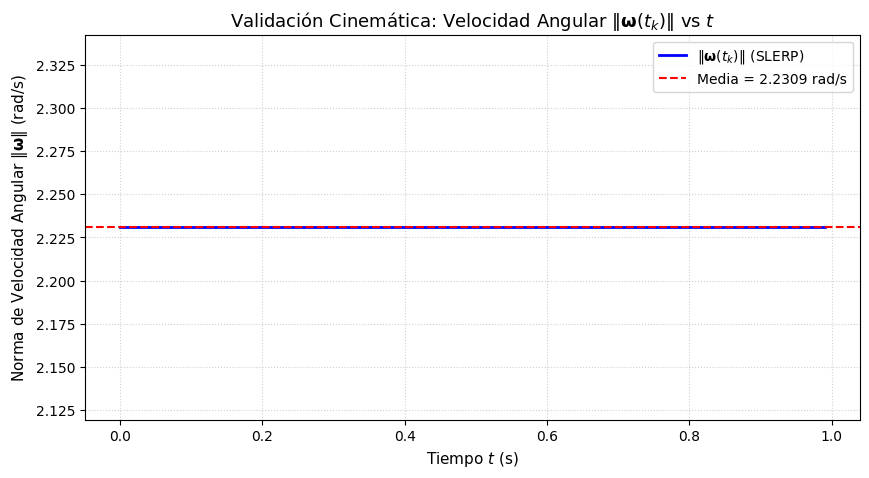

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# 1. GENERACIÓN DE LA TRAYECTORIA CON SLERP
q0 = Quaternion.from_euler_zyz(np.radians(0), np.radians(30), np.radians(0))
q1 = Quaternion.from_euler_zyz(np.radians(90), np.radians(60), np.radians(45))

N = 100
t_total = 1.0  # Tiempo total en segundos
t_steps = np.linspace(0.0, t_total, N)
dt = t_steps[1] - t_steps[0]

# Generación de cuaterniones e matrices de rotación
trayectoria_q = [slerp(q0, q1, t) for t in np.linspace(0.0, 1.0, N)]
R_list = [q.to_rotation_matrix() for q in trayectoria_q]


# 2. CÁLCULO DE VELOCIDAD ANGULAR W(t)
omega_norms = []
t_omega = t_steps[:-1]  # Tiempos para N-1 intervalos

for k in range(N - 1):
    # Aproximación por diferencias finitas: dR/dt * R^T
    dR_dt = (R_list[k+1] - R_list[k]) / dt
    skew_omega = np.dot(dR_dt, R_list[k].T)

    # Extraer componentes del vector omega
    wx = (skew_omega[2, 1] - skew_omega[1, 2]) / 2.0
    wy = (skew_omega[0, 2] - skew_omega[2, 0]) / 2.0
    wz = (skew_omega[1, 0] - skew_omega[0, 1]) / 2.0

    omega_vector = np.array([wx, wy, wz])
    omega_norms.append(np.linalg.norm(omega_vector))

omega_norms = np.array(omega_norms)


# 3. VALIDACIÓN ESTADÍSTICA DE CONSTANCIA
mean_omega = np.mean(omega_norms)
std_omega = np.std(omega_norms)
max_error_percent = np.max(np.abs(omega_norms - mean_omega) / mean_omega) * 100.0

print(f"Velocidad angular media ||w||: {mean_omega:.6f} rad/s")
print(f"Desviación estándar:           {std_omega:.6e}")
print(f"Error relativo máximo:         {max_error_percent:.4f}%")

if max_error_percent < 0.5:
    print("\nVALIDACIÓN EXITOSA: La velocidad angular se mantiene constante (Error < 0.5%).")
else:
    print("\nVALIDACIÓN FALLIDA: El error supera el límite de 0.5%.")


# 4. GRAFICACIÓN DE ||w(t_k)|| VS t
plt.figure(figsize=(10, 5))
plt.plot(t_omega, omega_norms, color='b', linewidth=2, label=r'$\|\mathbf{\omega}(t_k)\|$ (SLERP)')
plt.axhline(y=mean_omega, color='r', linestyle='--', label=f'Media = {mean_omega:.4f} rad/s')

plt.title(r'Validación Cinemática: Velocidad Angular $\|\mathbf{\omega}(t_k)\|$ vs $t$', fontsize=13)
plt.xlabel('Tiempo $t$ (s)', fontsize=11)
plt.ylabel(r'Norma de Velocidad Angular $\|\mathbf{\omega}\|$ (rad/s)', fontsize=11)
plt.ylim([mean_omega * 0.95, mean_omega * 1.05])  # Escala ajustada alrededor de la media
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()